In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
import pandas as pd
import numpy as np
import os

os.chdir('../../../results/PlantCAD2_tasks/')

In [2]:
species  = ['arabidopsis_thaliana', 'Ptr', 'Osa', 'Zma']
spKey = {'arabidopsis_thaliana': 'Arabidopsis thaliana',
        'Ptr': 'Populus trichocarpa',
        'Osa': 'Oryza sativa',
        'Zma': 'Zea mays'}
tasks = ['high_off_exp_angiosperm', 'on_off_exp_angiosperm', 'text']
ckpts = ['c8192_pcv2-l24-d0768-checkpoints-lr-1e-4', 'c2048_pcv2-l24-d0768-checkpoints-lr-1e-4']

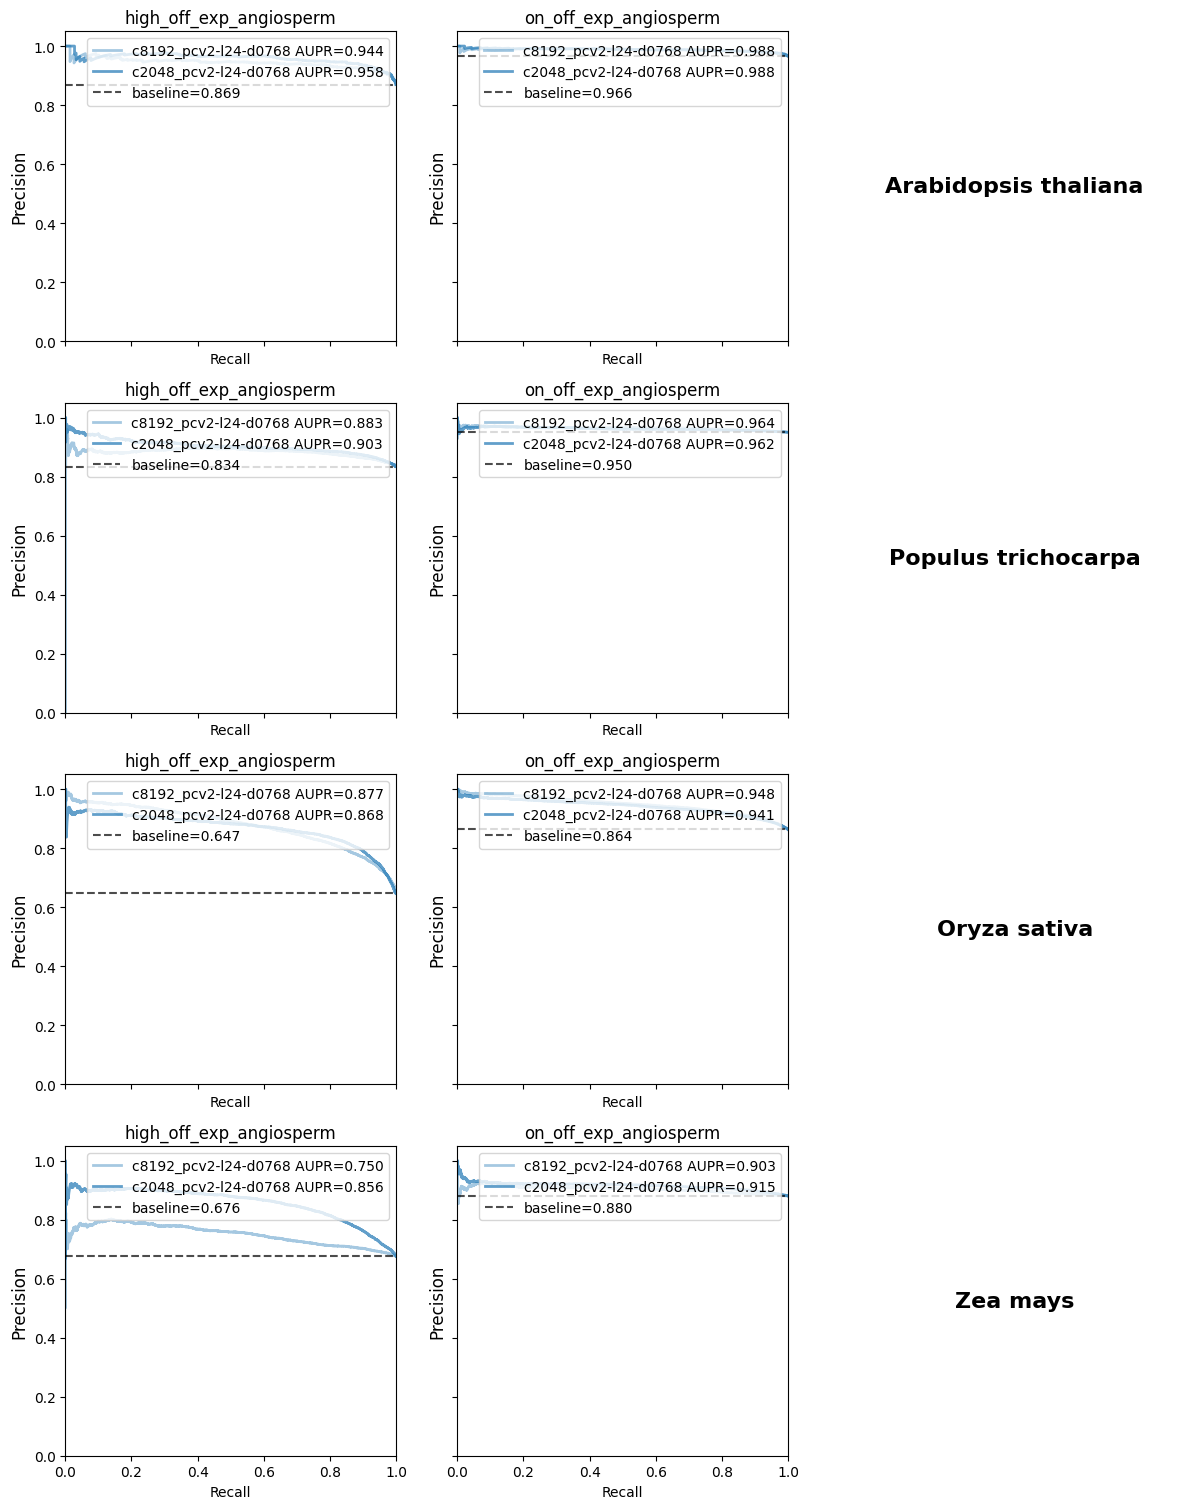

In [4]:
pcv2_alphas = [0.4, 0.7, 1.0]

# create a grid of axes: rows = species, cols = contexts
fig, axes = plt.subplots(
    nrows=len(species),
    ncols=len(tasks),
    figsize=(12, 4 * len(species)),
    sharex=True,
    sharey=True
)

for i, sp in enumerate(species):
    for j, task in enumerate(tasks):
        ax = axes[i, j]

        if j == 2:
            ax.clear()
            ax.axis('off')  # Turn off axis
            
            ax.text(
                0.5, 0.5,
                spKey.get(sp),  # Format species name
                ha='center',
                va='center',
                fontsize=16,
                fontweight='bold',
                transform=ax.transAxes
            )
            continue
        
        ap_scores = {}

        # loop through each checkpoint
        for k, ckpt in enumerate(ckpts):
            if sp == 'arabidopsis_thaliana':
                scores_path = (
                    f'{task}/models/{ckpt}/'
                    f'valid_scores.tsv'
                )
                labels_path = f'{task}/data/valid.tsv'
            else:
                scores_path = (
                    f'{task}/models/{ckpt}/'
                    f'test_{sp}_scores.tsv'
                )
                labels_path = f'{task}/data/test_{sp}.tsv'

            # load
            preds = pd.read_csv(scores_path, sep='\t')
            labs  = pd.read_csv(labels_path, sep='\t')

            y_scores = preds['probability_positive']
            y_true   = labs['Label']

            # compute PR & AP
            precision, recall, _ = precision_recall_curve(y_true, y_scores)
            ap = average_precision_score(y_true, y_scores)
            ap_scores[ckpt] = ap

            # pick color+alpha
            if 'agront' in ckpt.lower():
                color, alpha = 'gray', 1.0
            elif 'sup_pcv2' in ckpt.lower():
                color, alpha = 'C1', 1.0
            elif 'cnn' in ckpt.lower():
                color, alpha = 'C1', 0.5
            else:
                color = 'C0'
                alpha = pcv2_alphas[k]  # 0.4, 0.7, 1.0

            if 'cnn' in ckpt.lower():
                model_prefix = ckpt.replace('-imbalance-lr-1e-3', '')
            elif 'sup_pcv2' in ckpt.lower():
                model_prefix = ckpt.replace('-checkpoints-lr-1e-4', '')
            else:
                model_prefix = ckpt.replace('-checkpoints-lr-1e-4', '')
            # plot PR curve
            ax.plot(
                recall, precision,
                lw=2,
                color=color,
                alpha=alpha,
                label=f"{model_prefix} AUPR={ap:.3f}"
        )

        # baseline prevalence
        baseline = np.mean(y_true)
        ax.hlines(
            baseline, 0, 1,
            linestyle='--',
            linewidth=1.5,
            color='black',
            alpha=0.7,
            label=f'baseline={baseline:.3f}'
        )


        ax.set_title(task, fontsize=12)
        ax.set_ylabel(sp, fontsize=12)

        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.legend(loc='upper right')

# tighten and show
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('../../pipelines/expression/figures/pr_curves_all_species.pdf', format='pdf', bbox_inches='tight')
plt.show()

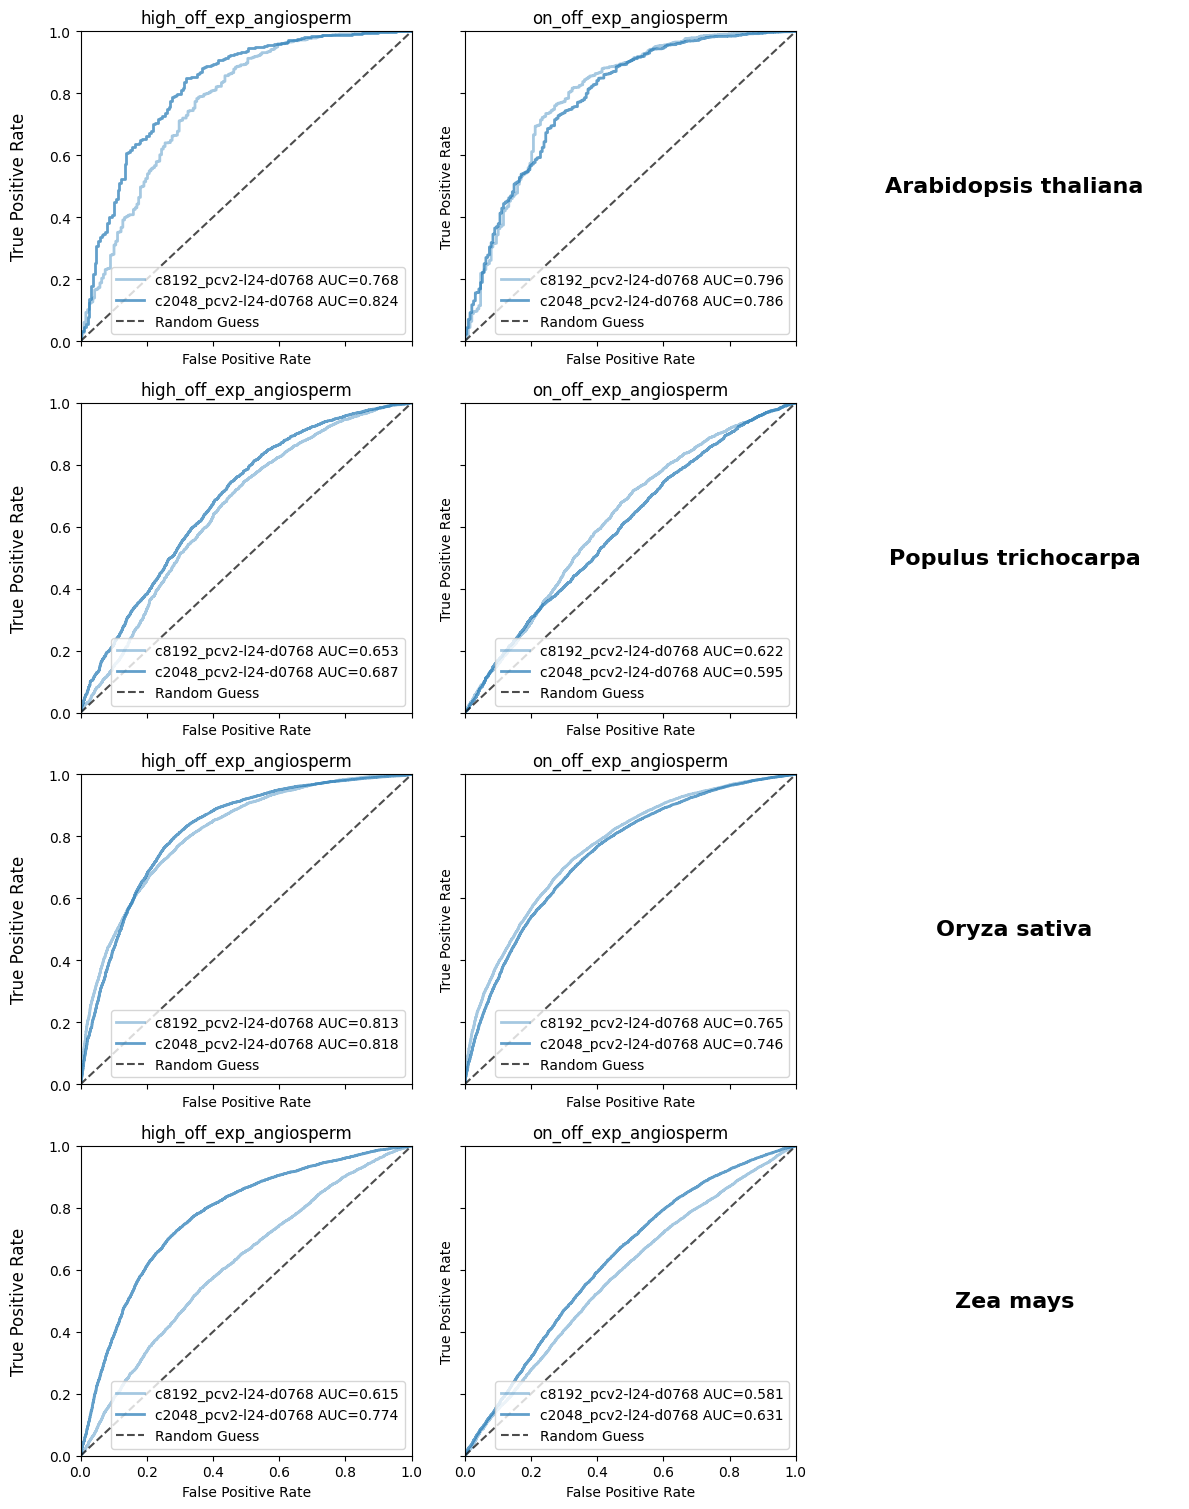

In [5]:
# create a grid of axes: rows = species, cols = tasks
fig, axes = plt.subplots(
    nrows=len(species),
    ncols=len(tasks),
    figsize=(12, 4 * len(species)),
    sharex=True,
    sharey=True
)

for i, sp in enumerate(species):
    for j, task in enumerate(tasks):
        ax = axes[i, j]
        if j == 2:
            ax.clear()
            ax.axis('off')  # Turn off axis
            
            # Display species name centered in the panel
            ax.text(
                0.5, 0.5,
                spKey.get(sp),
                ha='center',
                va='center',
                fontsize=16,
                fontweight='bold',
                transform=ax.transAxes
            )
            continue
            
        auc_scores = {}  # dictionary to save ROC AUC scores

        # loop through each checkpoint
        for k, ckpt in enumerate(ckpts):
            if sp == 'arabidopsis_thaliana':
                scores_path = f'{task}/models/{ckpt}/valid_scores.tsv'
                labels_path = f'{task}/data/valid.tsv'
            else:
                scores_path = f'{task}/models/{ckpt}/test_{sp}_scores.tsv'
                labels_path = f'{task}/data/test_{sp}.tsv'

            # load predictions and labels
            preds = pd.read_csv(scores_path, sep='\t')
            labs  = pd.read_csv(labels_path, sep='\t')

            y_scores = preds['probability_positive']
            y_true   = labs['Label']

            # compute ROC curve and AUC
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            roc_auc = roc_auc_score(y_true, y_scores)
            auc_scores[ckpt] = roc_auc

            # pick color and alpha based on checkpoint naming conventions
            if 'agront' in ckpt.lower():
                color, alpha = 'gray', 1.0
            elif 'sup_pcv2' in ckpt.lower():
                color, alpha = 'C1', 1.0
            elif 'cnn' in ckpt.lower():
                color, alpha = 'C1', 0.5
            else:
                color = 'C0'
                alpha = pcv2_alphas[k]  # 0.4, 0.7, 1.0

            # adjust model_prefix for the label
            if 'cnn' in ckpt.lower():
                model_prefix = ckpt.replace('-imbalance-lr-1e-3', '')
            elif 'sup_pcv2' in ckpt.lower():
                model_prefix = ckpt.replace('-checkpoints-lr-1e-4', '')
            else:
                model_prefix = ckpt.replace('-checkpoints-lr-1e-4', '')

            # plot ROC curve
            ax.plot(
                fpr, tpr,
                lw=2,
                color=color,
                alpha=alpha,
                label=f"{model_prefix} AUC={roc_auc:.3f}"
            )

        # plot baseline diagonal for random guessing
        ax.plot(
            [0, 1], [0, 1],
            linestyle='--',
            linewidth=1.5,
            color='black',
            alpha=0.7,
            label='Random Guess'
        )


        ax.set_title(task, fontsize=12)
        if j==0:
            ax.set_ylabel(sp, fontsize=12, labelpad=15)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc='lower right')

# tighten layout and show the plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../../pipelines/expression/figures/roc_curves_all_species.pdf', format='pdf', bbox_inches='tight')
plt.show()